In [1]:
import affine

In [2]:
from affine import Affine

```
| ScaleX   | SkewX     | TranslationX | 
| SkewY    | ScaleY    | TranslationY |
| 0        | 0         | 1            |           
```

```

```

```
| a   | b   | c   | 
| d   | e   | f   |
| 0   | 0   | 1   |

```

In [3]:
at = Affine(a=2.5, b=0, c=1, d=0, e=1.5, f=1)

def transform(a: Affine, row: int, col: int) -> tuple[float, float]:
    return a * (col, row)



In [4]:
transform(at, row=0, col=0)

(1.0, 1.0)

In [5]:
transform(at, row=0, col=2)

(6.0, 1.0)

In [6]:
transform(at, row=4, col=2)

(6.0, 7.0)

In [7]:
transform(at, row=4, col=0)

(1.0, 7.0)

In [8]:
transform(at, row=3, col=2)

(6.0, 5.5)

In [9]:
transform(at, row=1, col=2)

(6.0, 2.5)

In [10]:
import numpy as np
from IPython.display import Image, display
from sedona.spark import SedonaContext
import itertools
import os

In [11]:
%%capture
config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/30 19:53:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/30 19:53:25 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/11/30 19:53:25 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/11/30 19:53:25 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/11/30 19:53:25 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/11/30 19:53:25 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/11/30 19:53:25 WARN SimpleFunctionRegistry: The function st_envelop

In [12]:
# RS_MakeEmptyRaster(numBands: Integer, bandDataType: String = 'D', width: Integer, height: Integer, upperleftX: Double, upperleftY: Double, scaleX: Double, scaleY: Double, skewX: Double, skewY: Double, srid: Integer)
df = sedona.sql(
    "SELECT RS_MakeEmptyRaster(1, 'D', 5, 5, 1, 1, 2.5, 1.5, 0.0, 0.0, 4326) AS rast"
)

In [13]:
# in Sedona it's 1 indexed why 2, 1 is 3, 2
df.selectExpr("RS_PixelAsPoint(rast, 3, 2)").show()

+---------------------------+
|rs_pixelaspoint(rast, 3, 2)|
+---------------------------+
|              POINT (6 2.5)|
+---------------------------+



In [14]:
df.selectExpr("RS_PixelAsPoint(rast, 3, 1)").show()

+---------------------------+
|rs_pixelaspoint(rast, 3, 1)|
+---------------------------+
|                POINT (6 1)|
+---------------------------+



In [15]:
df.selectExpr("RS_PixelAsPoint(rast, 3, 5)").show()

+---------------------------+
|rs_pixelaspoint(rast, 3, 5)|
+---------------------------+
|                POINT (6 7)|
+---------------------------+



## Affine transformation types

In [16]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import io

In [17]:
raster_data = [
    [1, 1, 16, 2, 6],
    [2, 3, 12, 16, 17],
    [8, 17, 5, 20, 7],
    [14, 8, 15, 4, 11],
    [10, 13, 19, 6, 9]
]

def create_raster(scale_x=1, scale_y=1, skew_x=0, skew_y=0, trans_x=0, trans_y=0):
    flattened = list(itertools.chain.from_iterable(raster_data))
    array_input = ", ".join([str(number) for number in flattened ])
    
    shift_df = sedona.sql(
        f"SELECT RS_MakeEmptyRaster(1, 'D', 5, 5, {trans_x}, {trans_y}, {scale_x}, {scale_y}, {skew_x}, {skew_y}, 4326) AS rast"
    ).selectExpr(f"RS_MakeRaster(rast, 'D', ARRAY({array_input})) AS rast")

    return shift_df
    
def show_raster(df):
    rs = df.selectExpr("RS_AsGeoTiff(rast) AS binary").collect()[0]["binary"]
    with open("data.tif", "wb") as f:
        f.write(rs)
    with rasterio.open(io.BytesIO(rs)) as src:
        fig, ax = plt.subplots(figsize=(6, 4))
        show(src, ax=ax, cmap='terrain', transform=src.transform)
        plt.title("Raster from Bytearray")
        plt.show()

### translation

In [18]:
translation_df = create_raster(trans_x=5, trans_y=6)

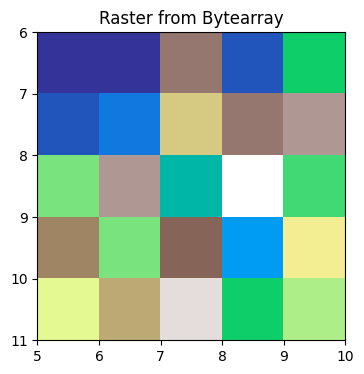

In [19]:
show_raster(translation_df)

### scaling

In [20]:
scale_df = create_raster(scale_x=5, scale_y=6)

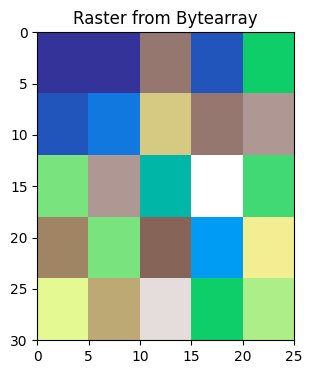

In [21]:
show_raster(scale_df)

### rotation

In [22]:
import math

rotate_df = create_raster(scale_x=0.5, scale_y=0.5, skew_x=-math.sqrt(3)/2, skew_y=math.sqrt(3)/2)

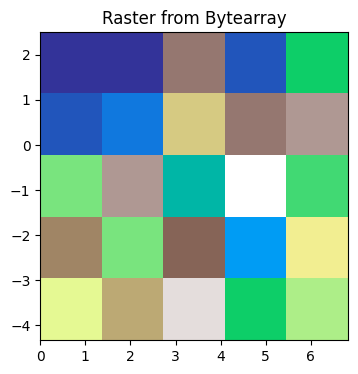

In [23]:
show_raster(rotate_df)